In [38]:
import pandas as pd

df = pd.read_json(
    "results/eval_7db_train_merged.jsonl",
    lines=True,
)
print(df.head())
print(df.shape)
print(df.columns.tolist())

  instance_id selected_database  \
0    gaming_1            gaming   
1    gaming_2            gaming   
2    gaming_3            gaming   
3    gaming_4            gaming   
4    gaming_5            gaming   

                                               query preprocess_sql  \
0  Can you identify gaming controllers that meet ...             []   
1  Analyze wireless and bluetooth devices' Batter...             []   
2  I want to analyze the RGB Implementation Quali...             []   
3  Show me all devices with a Battery Efficiency ...             []   
4  List all audio devices with an Audio Quality I...             []   

  clean_up_sqls                                            sol_sql  \
0            []  [\n/*\nAnalysis Goal: Identify devices that me...   
1            []  [\n/*\nAnalysis Goal: Analyze wireless devices...   
2            []  [\n/*\nAnalysis Goal: Analyze RGB lighting qua...   
3            []  [\n-- Intent: Identify devices with high batte...   
4           

In [39]:
df.to_csv("splits/lite_7db_train.csv", index=False)

## 1. Success rate per database

Note: you may need to restart the kernel to use updated packages.


,selected_database,tasks,passed,failed,success_rate
4,solar,15,6,9,40.0%
0,credit,15,5,10,33.3%
3,museum,15,5,10,33.3%
2,gaming,15,3,12,20.0%
1,cybermarket,15,2,13,13.3%


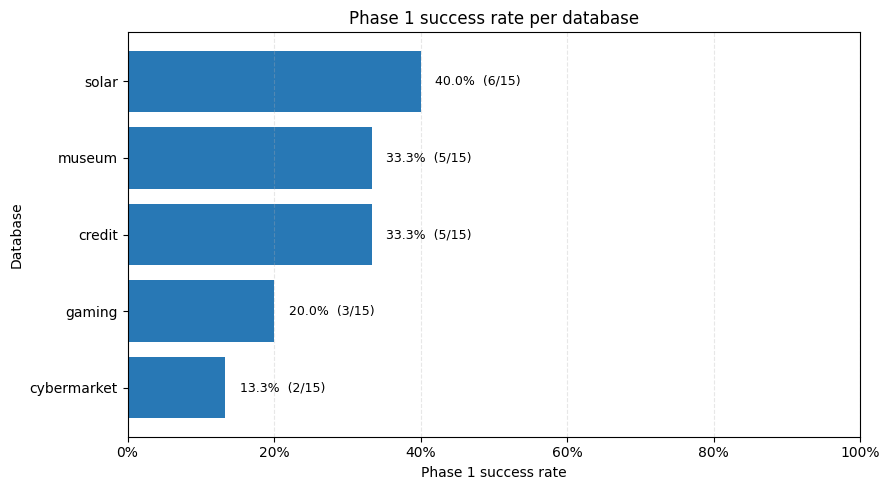

In [40]:
# Run once if matplotlib is unavailable in the notebook kernel.
%pip install -q matplotlib

import matplotlib.pyplot as plt

database_success = (
    df.assign(phase1_passed=df['phase1_passed'].astype(bool))
      .groupby('selected_database', as_index=False)['phase1_passed']
      .agg(tasks='size', passed='sum', success_rate='mean')
)
database_success['passed'] = database_success['passed'].astype(int)
database_success['failed'] = database_success['tasks'] - database_success['passed']
database_success = database_success.sort_values('success_rate', ascending=True)

display(
    database_success[['selected_database', 'tasks', 'passed', 'failed', 'success_rate']]
    .sort_values('success_rate', ascending=False)
    .style.format({'success_rate': '{:.1%}'})
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    database_success['selected_database'],
    database_success['success_rate'],
    color='#2878B5',
)
ax.set_xlim(0, 1)
ax.set_xlabel('Phase 1 success rate')
ax.set_ylabel('Database')
ax.set_title('Phase 1 success rate per database')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
ax.grid(axis='x', linestyle='--', alpha=0.3)

for bar, row in zip(bars, database_success.itertuples(index=False)):
    ax.text(
        min(row.success_rate + 0.02, 0.98),
        bar.get_y() + bar.get_height() / 2,
        f'{row.success_rate:.1%}  ({row.passed}/{row.tasks})',
        va='center',
        ha='right' if row.success_rate > 0.88 else 'left',
        fontsize=9,
    )

plt.tight_layout()
plt.show()

### Schema complexity by database

These measures describe the schema text available to the agent. `Graph cycles` is the undirected graph cycle rank, calculated as `foreign keys - tables + connected components`; a larger value indicates more independent cycles and potentially more alternative join routes. Because the exported schema records custom types only as `USER-DEFINED`, the analysis counts columns using a user-defined type rather than distinct custom type names.

In [41]:
from pathlib import Path
import json
import re
import numpy as np

def schema_metrics_for_database(database):
    folder = Path('livesqlbench-base-lite') / database
    schema_text = (folder / f'{database}_schema.txt').read_text()
    meanings = json.loads((folder / f'{database}_column_meaning_base.json').read_text())

    table_blocks = re.findall(
        r'CREATE TABLE\s+"([^"]+)"\s*\((.*?)\n\);',
        schema_text, flags=re.IGNORECASE | re.DOTALL,
    )
    table_names = [table for table, _ in table_blocks]
    columns = []
    foreign_keys = []

    for table, body in table_blocks:
        for raw_line in body.splitlines():
            line = raw_line.strip().rstrip(',')
            if not line:
                continue
            if line.upper().startswith('FOREIGN KEY'):
                reference = re.search(
                    r'FOREIGN KEY\s*\([^)]+\)\s+REFERENCES\s+([^\s(]+)',
                    line, flags=re.IGNORECASE,
                )
                if reference:
                    foreign_keys.append((table, reference.group(1).strip('"')))
            elif not line.upper().startswith(
                ('PRIMARY KEY', 'UNIQUE', 'CHECK', 'CONSTRAINT')
            ):
                columns.append({
                    'table': table,
                    'column': line.split()[0].strip('"'),
                    'definition': line,
                })

    # Undirected relationship graph: degree, components, and independent cycle rank.
    neighbours = {table: set() for table in table_names}
    degrees = {table: 0 for table in table_names}
    for source, target in foreign_keys:
        neighbours.setdefault(source, set()).add(target)
        neighbours.setdefault(target, set()).add(source)
        degrees[source] = degrees.get(source, 0) + 1
        degrees[target] = degrees.get(target, 0) + 1

    seen = set()
    components = 0
    for table in table_names:
        if table in seen:
            continue
        components += 1
        stack = [table]
        while stack:
            current = stack.pop()
            if current in seen:
                continue
            seen.add(current)
            stack.extend(neighbours.get(current, set()) - seen)

    descriptions = [value for value in meanings.values() if isinstance(value, str)]
    table_count = len(table_names)
    column_count = len(columns)
    fk_count = len(foreign_keys)
    return {
        'selected_database': database,
        'number_of_tables': table_count,
        'number_of_columns': column_count,
        'average_columns_per_table': column_count / table_count,
        'number_of_foreign_keys': fk_count,
        'foreign_keys_per_table': fk_count / table_count,
        'maximum_relationship_degree': max(degrees.values(), default=0),
        'graph_cycles': max(0, fk_count - table_count + components),
        'json_columns': sum(
            bool(re.search(r'\bjsonb?\b', item['definition'], re.IGNORECASE))
            for item in columns
        ),
        'user_defined_type_columns': sum(
            'USER-DEFINED' in item['definition'] for item in columns
        ),
        'average_column_name_length': sum(len(item['column']) for item in columns) / column_count,
        'schema_prompt_length': len(schema_text),
        'average_column_description_length': (
            sum(len(text) for text in descriptions) / len(descriptions)
        ),
    }

schema_metrics = pd.DataFrame(
    schema_metrics_for_database(database)
    for database in sorted(df['selected_database'].unique())
)
schema_analysis = database_success.merge(
    schema_metrics, on='selected_database', how='left', validate='one_to_one'
)
display(
    schema_analysis.sort_values('success_rate', ascending=False).style.format({
        'success_rate': '{:.1%}',
        'average_columns_per_table': '{:.2f}',
        'foreign_keys_per_table': '{:.2f}',
        'average_column_name_length': '{:.2f}',
        'average_column_description_length': '{:.2f}',
    })
)

,selected_database,tasks,passed,success_rate,failed,number_of_tables,number_of_columns,average_columns_per_table,number_of_foreign_keys,foreign_keys_per_table,maximum_relationship_degree,graph_cycles,json_columns,user_defined_type_columns,average_column_name_length,schema_prompt_length,average_column_description_length
4,solar,15,6,40.0%,9,8,84,10.50,12,1.50,5,5,3,0,9.95,13236,90.73
2,credit,15,5,33.3%,10,6,120,20.00,5,0.83,2,0,2,37,9.55,13721,69.88
3,museum,15,5,33.3%,10,14,185,13.21,21,1.50,8,8,0,9,13.48,25375,91.06
1,gaming,15,3,20.0%,12,8,160,20.00,12,1.50,4,5,0,8,8.74,16307,83.27
0,cybermarket,15,2,13.3%,13,9,132,14.67,16,1.78,5,8,3,39,11.32,19013,74.60


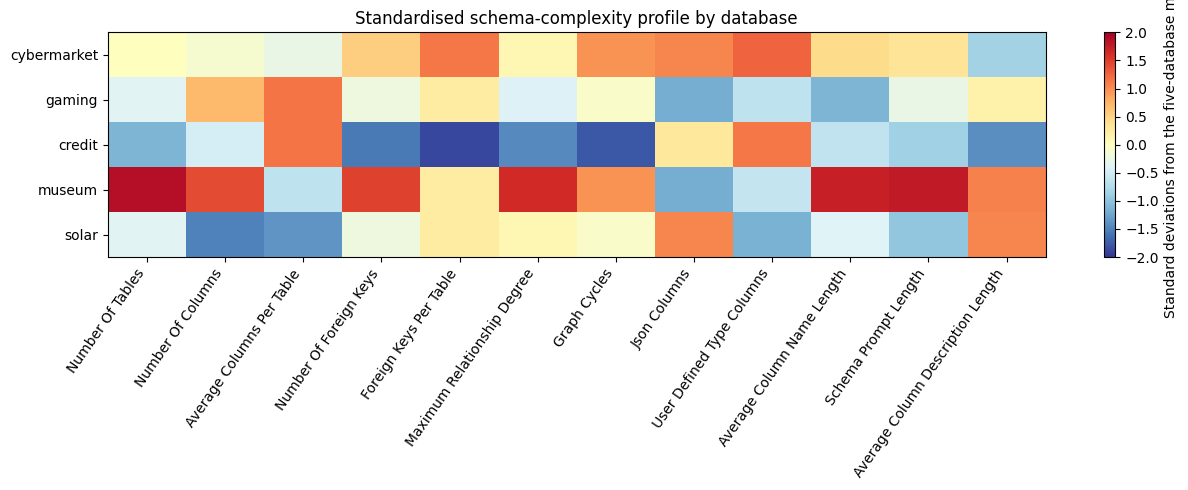

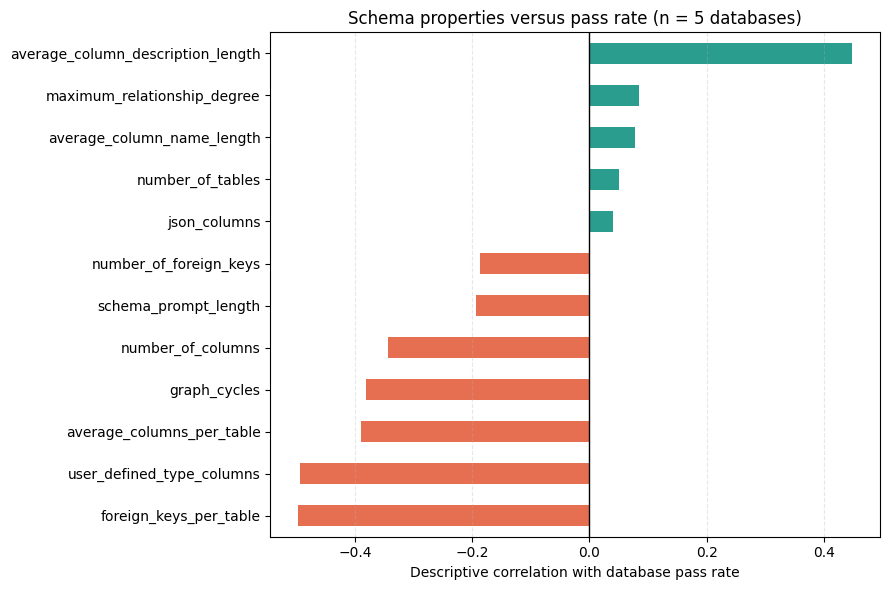

In [42]:
schema_feature_columns = [
    'number_of_tables', 'number_of_columns', 'average_columns_per_table',
    'number_of_foreign_keys', 'foreign_keys_per_table',
    'maximum_relationship_degree', 'graph_cycles', 'json_columns',
    'user_defined_type_columns', 'average_column_name_length',
    'schema_prompt_length', 'average_column_description_length',
]

# Standardise each measure so differently scaled schema properties can share one heatmap.
profile = schema_analysis.set_index('selected_database')[schema_feature_columns]
profile_z = (profile - profile.mean()) / profile.std(ddof=0).replace(0, 1)
fig, ax = plt.subplots(figsize=(13, 5))
image = ax.imshow(profile_z, cmap='RdYlBu_r', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(schema_feature_columns)))
ax.set_xticklabels([name.replace('_', ' ').title() for name in schema_feature_columns],
                   rotation=55, ha='right')
ax.set_yticks(range(len(profile_z)))
ax.set_yticklabels(profile_z.index)
ax.set_title('Standardised schema-complexity profile by database')
fig.colorbar(image, ax=ax, label='Standard deviations from the five-database mean')
plt.tight_layout()
plt.show()

# Descriptive association only: there are just five independent database observations.
schema_correlations = (
    schema_analysis[schema_feature_columns]
    .corrwith(schema_analysis['success_rate'])
    .sort_values()
)
fig, ax = plt.subplots(figsize=(9, 6))
colours = np.where(schema_correlations >= 0, '#2A9D8F', '#E76F51')
schema_correlations.plot.barh(ax=ax, color=colours)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Descriptive correlation with database pass rate')
ax.set_title('Schema properties versus pass rate (n = 5 databases)')
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretation

- Solar has the fewest columns and no columns marked `USER-DEFINED`, which may reduce schema-selection burden.
- Credit has the fewest foreign keys and no independent graph cycles, potentially making join-path selection simpler.
- Cybermarket combines relatively dense relationships, graph cycles, JSON columns, and many user-defined columns; these are plausible contributors to its lower pass rate.
- Gaming has the highest average number of columns per table, creating wide-table column-selection difficulty.
- Museum is the largest schema but performs as well as credit, showing that schema size alone cannot explain success.

These comparisons are exploratory. With only five independent databases, correlations are unstable and must not be interpreted as causal evidence. Task structure, domain semantics, and knowledge retrieval remain confounding factors.

## 2. Success rate per category

,category,tasks,passed,failed,success_rate
0,Management,25,9,16,36.0%
1,Query,50,12,38,24.0%


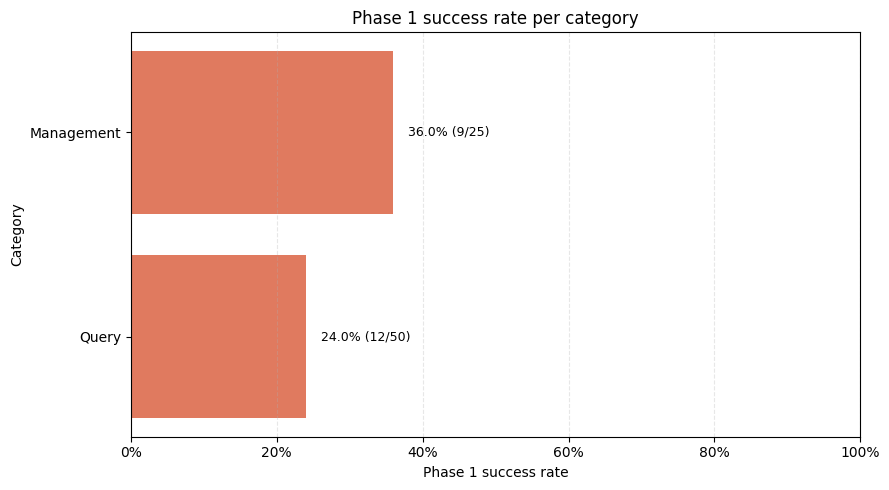

In [43]:
category_success = (
    df.assign(phase1_passed=df['phase1_passed'].astype(bool))
      .groupby('category', as_index=False)['phase1_passed']
      .agg(tasks='size', passed='sum', success_rate='mean')
)
category_success['passed'] = category_success['passed'].astype(int)
category_success['failed'] = category_success['tasks'] - category_success['passed']
category_success = category_success.sort_values('success_rate', ascending=True)

display(
    category_success[['category', 'tasks', 'passed', 'failed', 'success_rate']]
    .sort_values('success_rate', ascending=False)
    .style.format({'success_rate': '{:.1%}'})
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(category_success['category'], category_success['success_rate'], color='#E07A5F')
ax.set_xlim(0, 1)
ax.set_xlabel('Phase 1 success rate')
ax.set_ylabel('Category')
ax.set_title('Phase 1 success rate per category')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
ax.grid(axis='x', linestyle='--', alpha=0.3)
for bar, row in zip(bars, category_success.itertuples(index=False)):
    ax.text(
        min(row.success_rate + 0.02, 0.98),
        bar.get_y() + bar.get_height() / 2,
        f'{row.success_rate:.1%} ({row.passed}/{row.tasks})',
        va='center',
        ha='right' if row.success_rate > 0.88 else 'left',
        fontsize=9,
    )
plt.tight_layout()
plt.show()

## 3. External-knowledge use

For each task, extract the `id` from every `get_knowledge_definition` response. Repeated calls are retained. `external_knowledge use` is the number of extracted IDs divided by the number of expected IDs in `external_knowledge`; it is undefined (`NaN`) when no external knowledge is expected.

In [44]:
import json
import re
import numpy as np

def response_id(response):
    """Extract one ID from a get_knowledge_definition response."""
    if isinstance(response, dict):
        payload = response
    else:
        text = str(response or '').strip()
        try:
            payload = json.loads(text)
        except (json.JSONDecodeError, TypeError):
            match = re.search(r'"?id"?\s*:\s*"?(\d+)', text, re.IGNORECASE)
            return int(match.group(1)) if match else None

    # Also handle a nested JSON string, such as {'result': '{"id": 14, ...}'}.
    if isinstance(payload, dict) and 'id' in payload:
        try:
            return int(payload['id'])
        except (TypeError, ValueError):
            return payload['id']
    if isinstance(payload, dict) and 'result' in payload:
        return response_id(payload['result'])
    return None

def knowledge_ids_from_trajectory(trajectory):
    ids = []
    for call in trajectory if isinstance(trajectory, list) else []:
        if call.get('tool') == 'get_knowledge_definition':
            knowledge_id = response_id(call.get('result'))
            if knowledge_id is not None:
                ids.append(knowledge_id)
    return ids

df['knowledge_definition_ids'] = df['tool_trajectory'].apply(knowledge_ids_from_trajectory)
df['knowledge_definition_id_count'] = df['knowledge_definition_ids'].str.len()
df['external_knowledge_count'] = df['external_knowledge'].apply(
    lambda value: len(value) if isinstance(value, (list, tuple, set)) else 0
)
df['external_knowledge use'] = np.where(
    df['external_knowledge_count'].gt(0),
    df['knowledge_definition_id_count'] / df['external_knowledge_count'],
    np.nan,
)

display(df[[
    'instance_id', 'external_knowledge', 'knowledge_definition_ids',
    'knowledge_definition_id_count', 'external_knowledge_count',
    'external_knowledge use',
]].style.format({'external_knowledge use': '{:.1%}',}))

,instance_id,external_knowledge,knowledge_definition_ids,knowledge_definition_id_count,external_knowledge_count,external_knowledge use
0,gaming_1,"[2, 14]",[14],1,2,50.0%
1,gaming_2,"[1, 50]","[1, 50]",2,2,100.0%
2,gaming_3,"[6, 51]","[6, 51]",2,2,100.0%
3,gaming_4,[1],[],0,1,0.0%
4,gaming_5,[4],[],0,1,0.0%
5,gaming_6,"[1, 8, 35]","[35, 8, 1]",3,3,100.0%
6,gaming_7,"[7, 37]",[],0,2,0.0%
7,gaming_8,"[0, 2, 5, 30, 31, 38]",[],0,6,0.0%
8,gaming_9,[2],[],0,1,0.0%
9,gaming_10,"[0, 3, 10]","[0, 3, 10]",3,3,100.0%


### External-knowledge use levels by outcome

Separate tasks into `0%`, `0% < x < 100%`, `100%`, and `>100%`. Values above 100% occur when knowledge definitions are retrieved repeatedly.

,phase1_outcome,external_knowledge_use_group,task_count,outcome_percentage
0,Fail,0%,32,59.3%
1,Fail,0% < x < 100%,4,7.4%
2,Fail,100%,14,25.9%
3,Fail,>100%,4,7.4%
4,Pass,0%,5,23.8%
5,Pass,100%,14,66.7%
6,Pass,>100%,2,9.5%


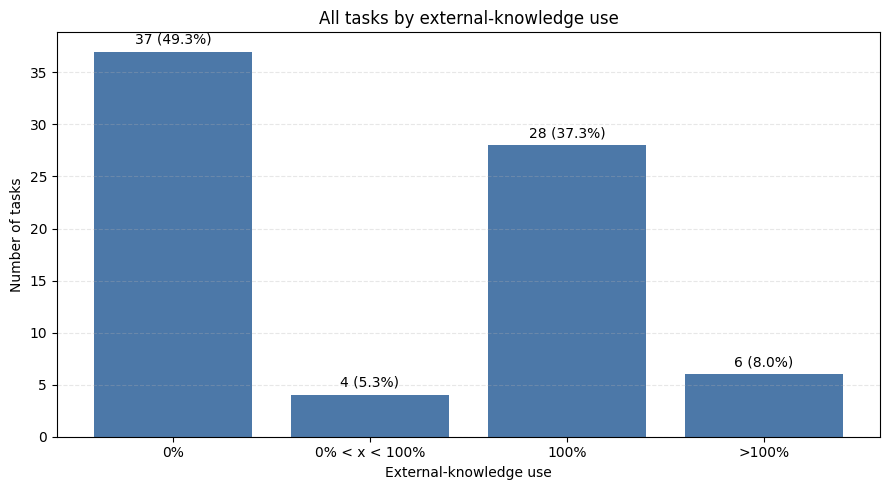

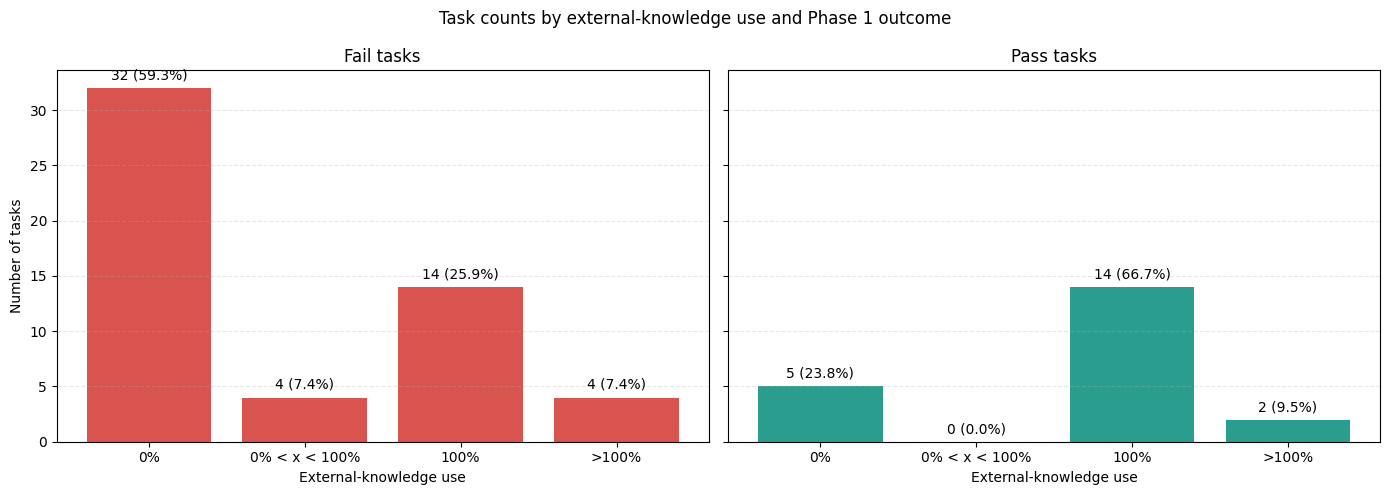

In [45]:
usage = df['external_knowledge use']
df['external_knowledge_use_group'] = np.select(
    [usage.eq(0), usage.gt(0) & usage.lt(1), usage.eq(1), usage.gt(1)],
    ['0%', '0% < x < 100%', '100%', '>100%'],
    default='Undefined',
)
df['phase1_outcome'] = np.where(df['phase1_passed'].astype(bool), 'Pass', 'Fail')

knowledge_outcome_counts = (
    df.groupby(['phase1_outcome', 'external_knowledge_use_group'], observed=True)
      .size()
      .rename('task_count')
      .reset_index()
)
knowledge_outcome_counts['outcome_percentage'] = (
    knowledge_outcome_counts['task_count']
    / knowledge_outcome_counts.groupby('phase1_outcome')['task_count'].transform('sum')
)
display(knowledge_outcome_counts.style.format({'outcome_percentage': '{:.1%}'}))

group_order = ['0%', '0% < x < 100%', '100%', '>100%']
overall_counts = (
    df['external_knowledge_use_group'].value_counts()
      .reindex(group_order, fill_value=0)
)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(group_order, overall_counts, color='#4C78A8')
ax.set_title('All tasks by external-knowledge use')
ax.set_xlabel('External-knowledge use')
ax.set_ylabel('Number of tasks')
ax.grid(axis='y', linestyle='--', alpha=0.3)
for bar, count in zip(bars, overall_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        f'{int(count)} ({count / len(df):.1%})',
        ha='center', va='bottom', fontsize=10,
    )
plt.tight_layout()
plt.show()

colours = {'Fail': '#D9534F', 'Pass': '#2A9D8F'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, outcome in zip(axes, ['Fail', 'Pass']):
    plot_data = (
        knowledge_outcome_counts.query('phase1_outcome == @outcome')
        .set_index('external_knowledge_use_group')
        .reindex(group_order, fill_value=0)
    )
    bars = ax.bar(group_order, plot_data['task_count'], color=colours[outcome])
    ax.set_title(f'{outcome} tasks')
    ax.set_xlabel('External-knowledge use')
    ax.set_ylabel('Number of tasks' if outcome == 'Fail' else '')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    total = int(plot_data['task_count'].sum())
    for bar, count in zip(bars, plot_data['task_count']):
        percentage = count / total if total else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{int(count)} ({percentage:.1%})',
            ha='center', va='bottom', fontsize=10,
        )

fig.suptitle('Task counts by external-knowledge use and Phase 1 outcome')
plt.tight_layout()
plt.show()

### External-knowledge use by category and outcome

The four panels split the usage counts by the two task categories and the two Phase 1 outcomes.

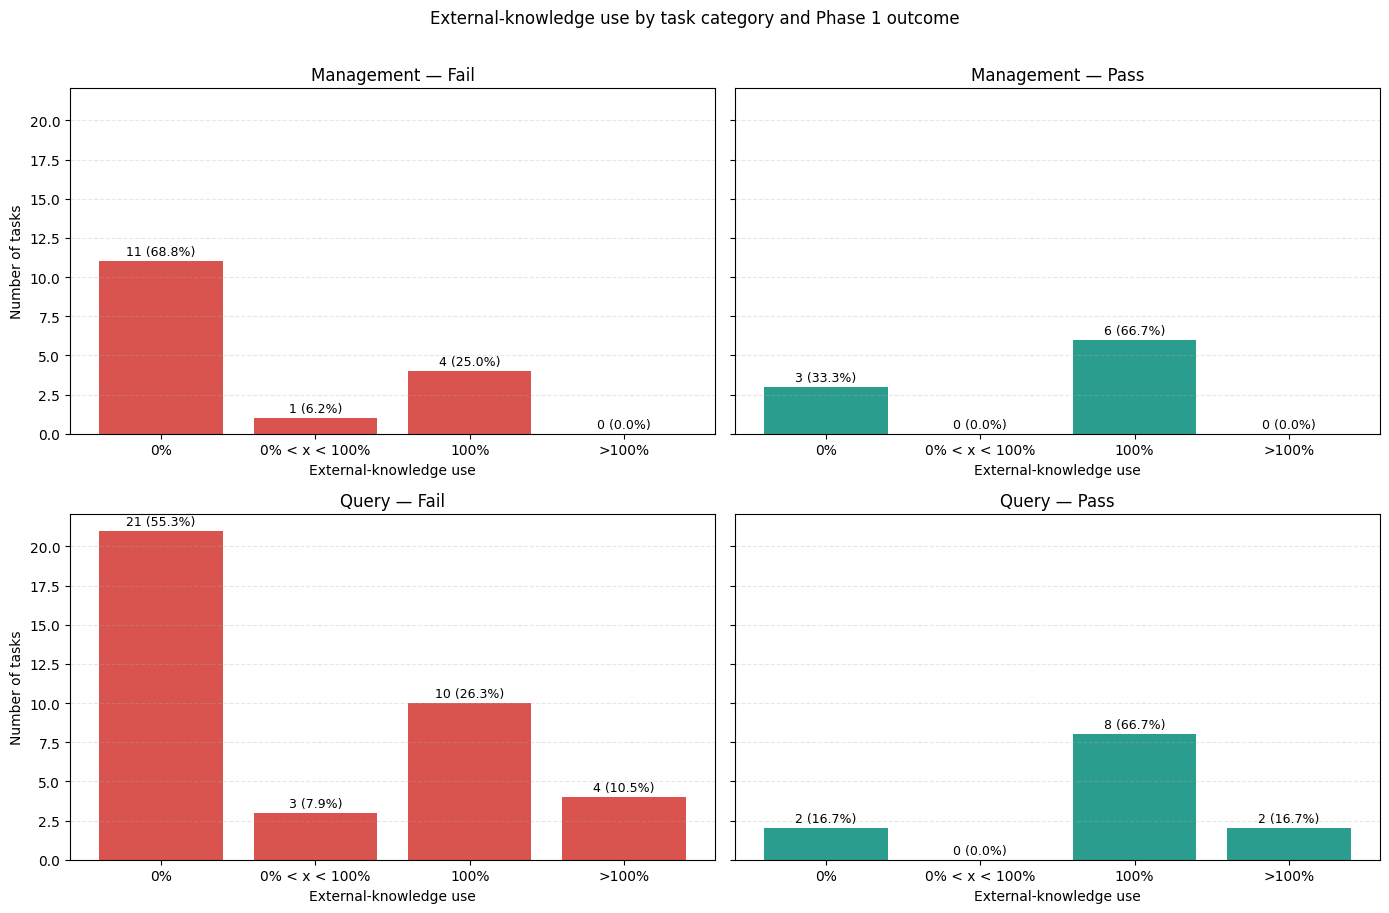

In [46]:
category_order = sorted(df['category'].dropna().unique())
outcome_order = ['Fail', 'Pass']
fig, axes = plt.subplots(
    len(category_order), 2,
    figsize=(14, 4.5 * len(category_order)),
    sharey=True, squeeze=False,
)

for row_index, category_name in enumerate(category_order):
    for column_index, outcome in enumerate(outcome_order):
        ax = axes[row_index, column_index]
        subset = df.loc[
            df['category'].eq(category_name) & df['phase1_outcome'].eq(outcome),
            'external_knowledge_use_group',
        ]
        counts = subset.value_counts().reindex(group_order, fill_value=0)
        bars = ax.bar(group_order, counts, color=colours[outcome])
        ax.set_title(f'{category_name} — {outcome}')
        ax.set_xlabel('External-knowledge use')
        ax.set_ylabel('Number of tasks' if column_index == 0 else '')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        total = int(counts.sum())
        for bar, count in zip(bars, counts):
            percentage = count / total if total else 0
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                f'{int(count)} ({percentage:.1%})',
                ha='center', va='bottom', fontsize=9,
            )

fig.suptitle('External-knowledge use by task category and Phase 1 outcome', y=1.01)
plt.tight_layout()
plt.show()

## SQL structure versus Phase 1 success

This analysis parses every PostgreSQL statement in `sol_sql`, assigns one primary task type, retains multi-label structural features, records numerical complexity, and compares individual features and combinations with `phase1_passed`.

In [47]:
# Run once if needed. sqlglot is also declared in requirements.txt.
%pip install -q sqlglot matplotlib

Note: you may need to restart the kernel to use updated packages.


In [48]:
from itertools import combinations
import math
import matplotlib.pyplot as plt
import numpy as np
import sqlglot
from sqlglot import exp

BOOLEAN_FEATURES = [
    'has_join', 'has_multi_join', 'has_cte', 'has_recursive_cte',
    'has_subquery', 'has_correlated_subquery', 'has_aggregate', 'has_window',
    'has_set_operation', 'has_json', 'has_case', 'has_distinct',
    'has_group_by', 'has_having', 'has_order_by', 'has_limit', 'has_where',
]
NUMERIC_FEATURES = [
    'statement_count', 'join_count', 'table_reference_count', 'unique_table_count',
    'cte_count', 'subquery_count', 'aggregate_count', 'window_count',
    'set_operation_count', 'case_count', 'select_count', 'max_ast_depth', 'sql_length',
]

def sql_items(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, str):
        return [value]
    return [str(item) for item in value if item is not None and str(item).strip()]

def ast_depth(node):
    children = list(node.iter_expressions())
    return 1 if not children else 1 + max(ast_depth(child) for child in children)

def is_json_node(node):
    return ('JSON' in type(node).__name__.upper() or
            (isinstance(node, exp.Func) and 'JSON' in node.sql_name().upper()))

def is_correlated(subquery):
    local_aliases = {table.alias_or_name for table in subquery.find_all(exp.Table)}
    refs = {column.table for column in subquery.find_all(exp.Column) if column.table}
    return bool(refs - local_aliases)

def extract_statement_features(ast, raw_sql):
    joins = list(ast.find_all(exp.Join))
    tables = list(ast.find_all(exp.Table))
    ctes = list(ast.find_all(exp.CTE))
    subqueries = list(ast.find_all(exp.Subquery))
    aggregates = list(ast.find_all(exp.AggFunc))
    windows = list(ast.find_all(exp.Window))
    set_ops = list(ast.find_all((exp.Union, exp.Intersect, exp.Except)))
    cases = list(ast.find_all(exp.Case))
    selects = list(ast.find_all(exp.Select))
    with_nodes = list(ast.find_all(exp.With))
    return {
        'statement_class': type(ast).__name__.upper(),
        'normalised_sql': ast.sql(dialect='postgres'),
        'has_join': bool(joins), 'has_multi_join': len(joins) >= 2,
        'has_cte': bool(ctes),
        'has_recursive_cte': any(bool(x.args.get('recursive')) for x in with_nodes),
        'has_subquery': bool(subqueries),
        'has_correlated_subquery': any(is_correlated(x) for x in subqueries),
        'has_aggregate': bool(aggregates), 'has_window': bool(windows),
        'has_set_operation': bool(set_ops),
        'has_json': any(is_json_node(x) for x in ast.walk()),
        'has_case': bool(cases),
        'has_distinct': any(x.args.get('distinct') is not None for x in selects),
        'has_group_by': any(x.args.get('group') is not None for x in selects),
        'has_having': any(x.args.get('having') is not None for x in selects),
        'has_order_by': any(x.args.get('order') is not None for x in selects),
        'has_limit': any(x.args.get('limit') is not None for x in selects),
        'has_where': any(x.args.get('where') is not None for x in selects),
        'join_count': len(joins), 'table_reference_count': len(tables),
        'unique_table_count': len({x.name.lower() for x in tables if x.name}),
        'cte_count': len(ctes), 'subquery_count': len(subqueries),
        'aggregate_count': len(aggregates), 'window_count': len(windows),
        'set_operation_count': len(set_ops), 'case_count': len(cases),
        'select_count': len(selects), 'max_ast_depth': ast_depth(ast),
        'sql_length': len(raw_sql),
    }

statement_rows = []
for task in df[['instance_id', 'sol_sql']].itertuples(index=False):
    statement_number = 0
    for item_number, sql_text in enumerate(sql_items(task.sol_sql), start=1):
        try:
            statements = sqlglot.parse(sql_text, dialect='postgres', error_level=sqlglot.ErrorLevel.RAISE)
            for ast in filter(None, statements):
                statement_number += 1
                statement_rows.append({
                    'instance_id': task.instance_id, 'sql_item': item_number,
                    'statement_number': statement_number, 'parse_ok': True,
                    'parse_error': None, 'raw_sql': sql_text,
                    **extract_statement_features(ast, sql_text),
                })
        except Exception as exc:
            statement_rows.append({
                'instance_id': task.instance_id, 'sql_item': item_number,
                'statement_number': None, 'parse_ok': False,
                'parse_error': str(exc), 'raw_sql': sql_text,
            })

statement_df = pd.DataFrame(statement_rows)
display(statement_df.head())
print('Parsed statements:', int(statement_df['parse_ok'].sum()))
print('Parse failures:', int((~statement_df['parse_ok']).sum()))
display(statement_df.loc[~statement_df['parse_ok'], ['instance_id', 'parse_error']])

'DO $$
DECLARE
    rec    RECORD;
    v_fsi  NUMERIC(5,3);
BEGIN
    FOR rec IN
        SELECT e.empl' contains unsupported syntax. Falling back to parsing as a 'Command'.
'CREATE OR REPLACE FUNCTION generate_performance_alert()
RETURNS TRIGGER AS $$
DECLARE
    panel_age ' contains unsupported syntax. Falling back to parsing as a 'Command'.


,instance_id,sql_item,statement_number,parse_ok,parse_error,raw_sql,statement_class,normalised_sql,has_join,has_multi_join,...,unique_table_count,cte_count,subquery_count,aggregate_count,window_count,set_operation_count,case_count,select_count,max_ast_depth,sql_length
0,gaming_1,1,1,True,None,\n/*\nAnalysis Goal: Identify devices that mee...,SELECT,/*\nAnalysis Goal: Identify devices that meet ...,True,True,...,5,2,0,0,0,0,1,3,14,1944
1,gaming_2,1,1,True,None,\n/*\nAnalysis Goal: Analyze wireless devices ...,SELECT,/*\nAnalysis Goal: Analyze wireless devices ba...,True,False,...,3,1,0,1,1,0,1,2,10,1516
2,gaming_3,1,1,True,None,\n/*\nAnalysis Goal: Analyze RGB lighting qual...,SELECT,/*\nAnalysis Goal: Analyze RGB lighting qualit...,True,True,...,5,1,0,0,0,0,1,2,11,1591
3,gaming_4,1,1,True,None,\n-- Intent: Identify devices with high batter...,SELECT,/* Intent: Identify devices with high battery ...,True,False,...,2,0,0,0,0,0,0,1,8,468
4,gaming_5,1,1,True,None,\n-- [Normal] List devices with high Audio Qua...,SELECT,/* [Normal] List devices with high Audio Quali...,True,False,...,2,0,0,0,0,0,0,1,11,552


Parsed statements: 97
Parse failures: 0


,instance_id,parse_error


In [49]:
def assign_primary_type(row):
    classes = set(row['statement_classes'])
    if classes & {'CREATE', 'ALTER', 'DROP', 'TRUNCATETABLE', 'COMMAND'}: return 'DDL'
    if classes & {'INSERT', 'UPDATE', 'DELETE', 'MERGE'}: return 'DML'
    if row['has_set_operation']: return 'SET_OPERATION_QUERY'
    if row['has_cte']: return 'CTE_QUERY'
    if row['has_multi_join']: return 'MULTI_JOIN_QUERY'
    if row['has_join']: return 'JOIN_QUERY'
    if row['has_aggregate'] or row['has_group_by']: return 'AGGREGATION_QUERY'
    if 'SELECT' in classes: return 'SIMPLE_QUERY'
    return 'OTHER'

parsed = statement_df.query('parse_ok').copy()
agg = {x: 'max' for x in BOOLEAN_FEATURES}
agg.update({x: 'sum' for x in NUMERIC_FEATURES if x not in {'statement_count', 'max_ast_depth'}})
agg['max_ast_depth'] = 'max'
agg['statement_class'] = lambda values: sorted(set(values))
task_features = (parsed.groupby('instance_id', as_index=False).agg(agg)
                 .rename(columns={'statement_class': 'statement_classes'}))
counts = parsed.groupby('instance_id').size()
task_features['statement_count'] = task_features['instance_id'].map(counts)
task_features['primary_task_type'] = task_features.apply(assign_primary_type, axis=1)
analysis_df = df.merge(task_features, on='instance_id', how='left', validate='one_to_one')
analysis_df['phase1_passed'] = analysis_df['phase1_passed'].astype(bool)
analysis_df['passed_int'] = analysis_df['phase1_passed'].astype(int)
missing = analysis_df.loc[analysis_df['primary_task_type'].isna(), 'instance_id'].tolist()
if missing: raise ValueError(f'Tasks without parsed SQL: {missing}')
display(analysis_df[['instance_id', 'primary_task_type', *BOOLEAN_FEATURES, *NUMERIC_FEATURES]].head())

,instance_id,primary_task_type,has_join,has_multi_join,has_cte,has_recursive_cte,has_subquery,has_correlated_subquery,has_aggregate,has_window,...,unique_table_count,cte_count,subquery_count,aggregate_count,window_count,set_operation_count,case_count,select_count,max_ast_depth,sql_length
0,gaming_1,CTE_QUERY,True,True,True,False,False,False,False,False,...,5,2,0,0,0,0,1,3,14,1944
1,gaming_2,CTE_QUERY,True,False,True,False,False,False,True,True,...,3,1,0,1,1,0,1,2,10,1516
2,gaming_3,CTE_QUERY,True,True,True,False,False,False,False,False,...,5,1,0,0,0,0,1,2,11,1591
3,gaming_4,JOIN_QUERY,True,False,False,False,False,False,False,False,...,2,0,0,0,0,0,0,1,8,468
4,gaming_5,JOIN_QUERY,True,False,False,False,False,False,False,False,...,2,0,0,0,0,0,0,1,11,552


,tasks,passed,pass_rate
primary_task_type,,,
SET_OPERATION_QUERY,1,0,0.0%
JOIN_QUERY,6,1,16.7%
CTE_QUERY,28,5,17.9%
MULTI_JOIN_QUERY,7,2,28.6%
SIMPLE_QUERY,6,2,33.3%
DDL,20,7,35.0%
DML,5,2,40.0%
AGGREGATION_QUERY,2,2,100.0%


,feature,tasks_with_feature,pass_rate_with,pass_rate_without,pass_rate_difference
11,has_distinct,3,0.0%,29.2%,-29.2%
8,has_set_operation,1,0.0%,28.4%,-28.4%
13,has_having,1,0.0%,28.4%,-28.4%
0,has_join,41,17.1%,41.2%,-24.1%
16,has_where,37,16.2%,39.5%,-23.3%
1,has_multi_join,29,13.8%,37.0%,-23.2%
2,has_cte,29,17.2%,34.8%,-17.5%
7,has_window,5,20.0%,28.6%,-8.6%
14,has_order_by,30,23.3%,31.1%,-7.8%
9,has_json,12,25.0%,28.6%,-3.6%


,mean,median,max,correlation_with_pass
max_ast_depth,11.333333,11.000000,20,-0.309
table_reference_count,3.626667,3.000000,15,-0.290
unique_table_count,3.200000,3.000000,10,-0.284
join_count,1.400000,1.000000,9,-0.244
cte_count,0.720000,0.000000,5,-0.158
select_count,1.613333,1.000000,6,-0.153
sql_length,1500.106667,1185.000000,6405,-0.137
statement_count,1.293333,1.000000,5,-0.133
window_count,0.093333,0.000000,2,-0.077
set_operation_count,0.013333,0.000000,1,-0.072


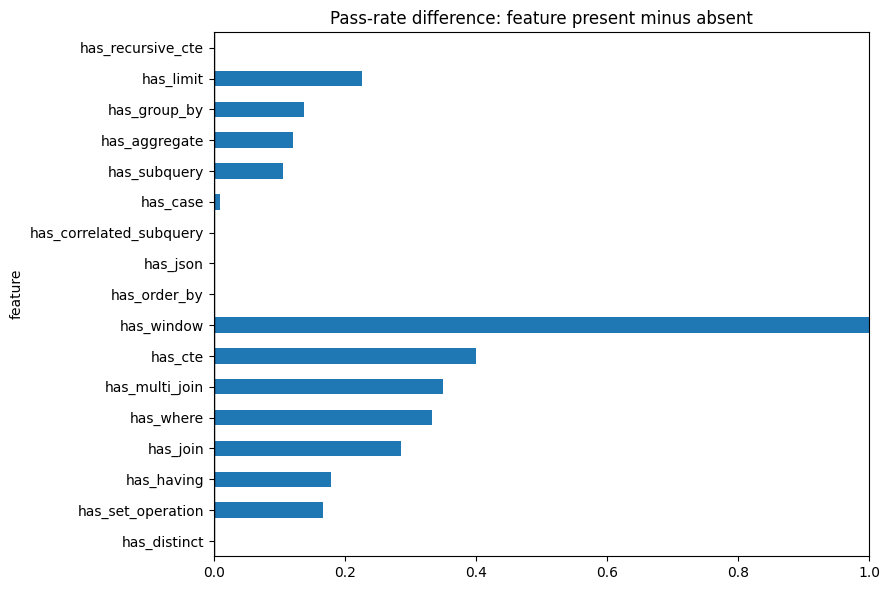

In [50]:
primary_summary = (analysis_df.groupby('primary_task_type')['passed_int']
                   .agg(tasks='size', passed='sum', pass_rate='mean')
                   .sort_values('pass_rate'))
display(primary_summary.style.format({'pass_rate': '{:.1%}'}))
primary_summary['pass_rate'].plot.barh(figsize=(8, 4), xlim=(0, 1),
    title='Phase 1 pass rate by primary SQL task type')
plt.xlabel('Pass rate'); plt.tight_layout()

feature_rows = []
for feature in BOOLEAN_FEATURES:
    present = analysis_df[feature].astype(bool)
    yes = analysis_df.loc[present, 'passed_int']
    no = analysis_df.loc[~present, 'passed_int']
    feature_rows.append({
        'feature': feature, 'tasks_with_feature': len(yes),
        'pass_rate_with': yes.mean(), 'pass_rate_without': no.mean(),
        'pass_rate_difference': yes.mean() - no.mean(),
    })
feature_summary = pd.DataFrame(feature_rows).sort_values('pass_rate_difference')
display(feature_summary.style.format({
    'pass_rate_with': '{:.1%}', 'pass_rate_without': '{:.1%}',
    'pass_rate_difference': '{:+.1%}',
}))
feature_summary.set_index('feature')['pass_rate_difference'].plot.barh(
    figsize=(9, 6), title='Pass-rate difference: feature present minus absent')
plt.axvline(0, color='black', linewidth=1); plt.tight_layout()

numeric_summary = pd.DataFrame({
    'mean': analysis_df[NUMERIC_FEATURES].mean(),
    'median': analysis_df[NUMERIC_FEATURES].median(),
    'max': analysis_df[NUMERIC_FEATURES].max(),
    'correlation_with_pass': [analysis_df[x].corr(analysis_df['passed_int'])
                              if analysis_df[x].nunique() > 1 else np.nan
                              for x in NUMERIC_FEATURES],
}).sort_values('correlation_with_pass')
display(numeric_summary.style.format({'correlation_with_pass': '{:+.3f}'}))

In [51]:
COMBINATION_FEATURES = [
    'has_multi_join', 'has_cte', 'has_subquery', 'has_aggregate',
    'has_window', 'has_set_operation', 'has_json', 'has_case',
]
MIN_SUPPORT = 3
analysis_df['feature_signature'] = analysis_df[COMBINATION_FEATURES].apply(
    lambda row: ' + '.join(k.removeprefix('has_').upper()
                           for k, present in row.items() if present) or 'NONE', axis=1)
signature_summary = (analysis_df.groupby('feature_signature')['passed_int']
    .agg(tasks='size', passed='sum', pass_rate='mean')
    .query('tasks >= @MIN_SUPPORT').sort_values(['pass_rate', 'tasks']))
display(signature_summary.style.format({'pass_rate': '{:.1%}'}))

pairs = []
for left, right in combinations(COMBINATION_FEATURES, 2):
    outcome = analysis_df.loc[analysis_df[left] & analysis_df[right], 'passed_int']
    if len(outcome) >= MIN_SUPPORT:
        pairs.append({'combination': f"{left[4:].upper()} + {right[4:].upper()}",
                      'tasks': len(outcome), 'passed': int(outcome.sum()),
                      'pass_rate': outcome.mean()})
pair_summary = pd.DataFrame(pairs).sort_values(['pass_rate', 'tasks'])
display(pair_summary.style.format({'pass_rate': '{:.1%}'}))

,tasks,passed,pass_rate
feature_signature,,,
MULTI_JOIN,3,0,0.0%
MULTI_JOIN + CTE,3,0,0.0%
MULTI_JOIN + CTE + CASE,6,1,16.7%
CASE,4,1,25.0%
NONE,23,7,30.4%
CTE + CASE,3,1,33.3%
MULTI_JOIN + CTE + AGGREGATE + CASE,3,1,33.3%
JSON,3,2,66.7%


,combination,tasks,passed,pass_rate
11,AGGREGATE + JSON,3,0,0.0%
13,WINDOW + CASE,3,0,0.0%
6,CTE + WINDOW,4,0,0.0%
3,MULTI_JOIN + JSON,7,0,0.0%
0,MULTI_JOIN + CTE,19,2,10.5%
7,CTE + JSON,7,1,14.3%
2,MULTI_JOIN + AGGREGATE,9,2,22.2%
5,CTE + AGGREGATE,9,2,22.2%
8,CTE + CASE,18,4,22.2%
4,MULTI_JOIN + CASE,17,4,23.5%


**Interpretation:** these pass-rate differences are descriptive associations, not causal effects. Always report support counts, be cautious with rare combinations, and check `selected_database` and `difficulty_tier` as possible confounders.

In [52]:
# Optional analysis outputs
analysis_df.to_parquet('results/eval_7db_train_sql_features.parquet', index=False)
statement_df.to_json('results/eval_7db_train_sql_statements.jsonl', orient='records', lines=True)
feature_summary.to_csv('results/eval_7db_train_feature_summary.csv', index=False)
pair_summary.to_csv('results/eval_7db_train_feature_combinations.csv', index=False)

## Success rate by task type and structural difficulty

Difficulty is derived from the ground-truth SQL breakdown, independently of the dataset's existing `difficulty_tier`. For **Query** tasks, `easy` means one table without joins or nesting; `non_nested_complex` means joins without CTEs, subqueries, or set operations; and `nested_complex` means a CTE, subquery, or set operation is present. For **Management** tasks, `easy` means a single-target change without relational dependencies or procedural logic; `non_nested_complex` means the change depends on joins, CTEs, subqueries, aggregation, windows, set operations, or multiple referenced tables; and `nested_complex` means procedural SQL or dependent changes across multiple database objects.

The classifier retains a reason and its extracted management features for auditing. `COMMENT` and `GRANT` do not independently increase complexity.

In [53]:
from sql_difficulty import DIFFICULTY_ORDER, add_structural_difficulty, success_summaries

analysis_df = add_structural_difficulty(analysis_df)
task_type_success, difficulty_success = success_summaries(analysis_df)

display(analysis_df[[
    'instance_id', 'category', 'structural_difficulty', 'difficulty_reason',
    'has_join', 'has_cte', 'has_subquery', 'has_set_operation',
    'management_has_procedural_sql', 'management_modified_objects',
]].head(20))

,instance_id,category,structural_difficulty,difficulty_reason,has_join,has_cte,has_subquery,has_set_operation,management_has_procedural_sql,management_modified_objects
0,gaming_1,Query,nested_complex,"query contains CTE, subquery, or set operation",True,True,False,False,False,[]
1,gaming_2,Query,nested_complex,"query contains CTE, subquery, or set operation",True,True,False,False,False,[]
2,gaming_3,Query,nested_complex,"query contains CTE, subquery, or set operation",True,True,False,False,False,[]
3,gaming_4,Query,non_nested_complex,query joins or references multiple tables with...,True,False,False,False,False,[]
4,gaming_5,Query,non_nested_complex,query joins or references multiple tables with...,True,False,False,False,False,[]
5,gaming_6,Query,nested_complex,"query contains CTE, subquery, or set operation",True,True,False,False,False,[]
6,gaming_7,Query,nested_complex,"query contains CTE, subquery, or set operation",False,True,False,False,False,[]
7,gaming_8,Query,nested_complex,"query contains CTE, subquery, or set operation",True,True,False,False,False,[]
8,gaming_9,Query,non_nested_complex,query joins or references multiple tables with...,True,False,False,False,False,[]
9,gaming_10,Query,nested_complex,"query contains CTE, subquery, or set operation",True,False,True,False,False,[]


,category,tasks,passed,success_rate,failed
0,Management,25,9,36.0%,16
1,Query,50,12,24.0%,38


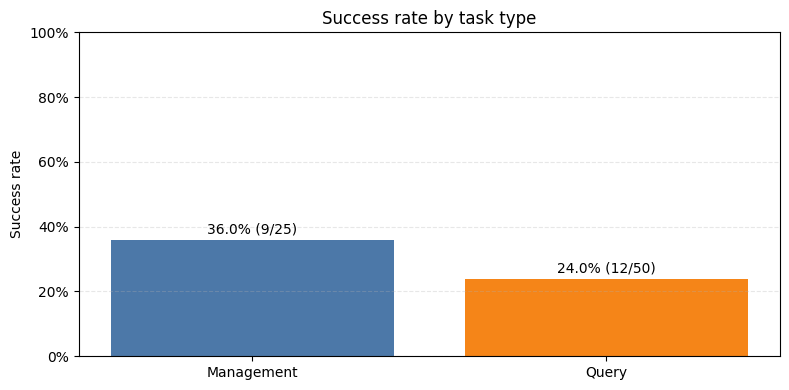

In [54]:
display(task_type_success.style.format({'success_rate': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(task_type_success['category'], task_type_success['success_rate'],
              color=['#4C78A8', '#F58518'])
ax.set_ylim(0, 1); ax.set_ylabel('Success rate'); ax.set_title('Success rate by task type')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
ax.grid(axis='y', linestyle='--', alpha=0.3)
for bar, row in zip(bars, task_type_success.itertuples(index=False)):
    ax.text(bar.get_x() + bar.get_width()/2, row.success_rate + 0.02,
            f'{row.success_rate:.1%} ({row.passed}/{row.tasks})', ha='center')
plt.tight_layout(); plt.show()

,category,structural_difficulty,tasks,passed,success_rate,failed
0,Management,easy,3,3,100.0%,0
1,Management,non_nested_complex,9,2,22.2%,7
2,Management,nested_complex,13,4,30.8%,9
3,Query,easy,8,4,50.0%,4
4,Query,non_nested_complex,11,1,9.1%,10
5,Query,nested_complex,31,7,22.6%,24


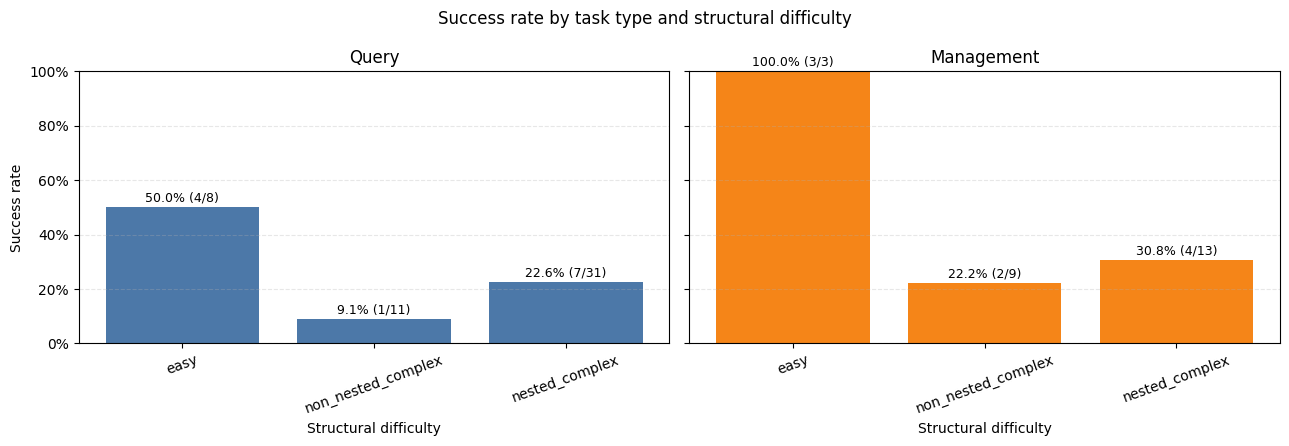

In [55]:
display(difficulty_success.style.format({'success_rate': '{:.1%}'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
colours = {'Query': '#4C78A8', 'Management': '#F58518'}
for ax, category_name in zip(axes, ['Query', 'Management']):
    plot_data = (difficulty_success[difficulty_success['category'].eq(category_name)]
                 .set_index('structural_difficulty').reindex(DIFFICULTY_ORDER))
    bars = ax.bar(DIFFICULTY_ORDER, plot_data['success_rate'], color=colours[category_name])
    ax.set_ylim(0, 1); ax.set_title(category_name); ax.set_xlabel('Structural difficulty')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
    ax.tick_params(axis='x', rotation=20); ax.grid(axis='y', linestyle='--', alpha=0.3)
    for bar, row in zip(bars, plot_data.itertuples()):
        label = 'n=0' if row.tasks == 0 else f'{row.success_rate:.1%} ({int(row.passed)}/{int(row.tasks)})'
        height = 0 if pd.isna(row.success_rate) else row.success_rate
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, label, ha='center', fontsize=9)
axes[0].set_ylabel('Success rate')
fig.suptitle('Success rate by task type and structural difficulty')
plt.tight_layout(); plt.show()

analysis_df.to_csv('results/eval_7db_train_classified_tasks.csv', index=False)
task_type_success.to_csv('results/eval_7db_train_success_by_task_type.csv', index=False)
difficulty_success.to_csv('results/eval_7db_train_success_by_difficulty.csv', index=False)

## Schema-linking accuracy

The agent's selected schema is inferred from its final `submit_sql` call, falling back to its last `execute_sql` call. Ground truth comes from `sol_sql`. Table and KB selection report precision (how much of the selection was correct), recall (how much ground truth was selected), F1, and exact-set match. Repeated KB retrievals count once.

Join-path correctness compares canonical qualified equi-join edges, including both table and column names. It is an exact-reference metric: an alternative semantically valid join path may be marked different. Tasks whose reference SQL has no extractable qualified join edge are excluded from join-path aggregate accuracy.

In [56]:
from schema_linking_metrics import add_schema_linking_metrics, micro_scores

analysis_df = add_schema_linking_metrics(analysis_df)
display(analysis_df[[
    'instance_id', 'category', 'selected_tables', 'ground_truth_tables',
    'table_precision', 'table_recall', 'table_f1', 'table_exact_match',
    'join_path_correct', 'selected_kb_ids_unique', 'ground_truth_kb_ids',
    'kb_precision', 'kb_recall', 'kb_f1', 'kb_exact_match',
]].style.format({
    'table_precision': '{:.1%}', 'table_recall': '{:.1%}', 'table_f1': '{:.1%}',
    'kb_precision': '{:.1%}', 'kb_recall': '{:.1%}', 'kb_f1': '{:.1%}',
}))

'DO $$
BEGIN
  IF NOT EXISTS (
    SELECT 1
    FROM pg_type
    WHERE typname = 'battery_efficiency_' contains unsupported syntax. Falling back to parsing as a 'Command'.
'DO $$
BEGIN
  UPDATE employment_and_income e
  SET fsi = (
    0.35 * COALESCE(e.incstabscore, 0)::n' contains unsupported syntax. Falling back to parsing as a 'Command'.
'DO $$
DECLARE
    rec    RECORD;
    v_fsi  NUMERIC(5,3);
BEGIN
    FOR rec IN
        SELECT e.empl' contains unsupported syntax. Falling back to parsing as a 'Command'.
'CREATE OR REPLACE FUNCTION generate_performance_alert()
RETURNS trigger
LANGUAGE plpgsql
AS $$
DECLA' contains unsupported syntax. Falling back to parsing as a 'Command'.
'CREATE OR REPLACE FUNCTION generate_performance_alert()
RETURNS TRIGGER AS $$
DECLARE
    panel_age ' contains unsupported syntax. Falling back to parsing as a 'Command'.


,instance_id,category,selected_tables,ground_truth_tables,table_precision,table_recall,table_f1,table_exact_match,join_path_correct,selected_kb_ids_unique,ground_truth_kb_ids,kb_precision,kb_recall,kb_f1,kb_exact_match
0,gaming_1,Query,"['deviceidentity', 'interactionandcontrol', 'testsessions']","['deviceidentity', 'interactionandcontrol', 'testsessions']",100.0%,100.0%,100.0%,True,False,[14],"[14, 2]",100.0%,50.0%,66.7%,False
1,gaming_2,Query,"['deviceidentity', 'testsessions']","['deviceidentity', 'testsessions']",100.0%,100.0%,100.0%,True,True,"[1, 50]","[1, 50]",100.0%,100.0%,100.0%,True
2,gaming_3,Query,"['deviceidentity', 'mechanical', 'rgb', 'testsessions']","['deviceidentity', 'mechanical', 'rgb', 'testsessions']",100.0%,100.0%,100.0%,True,True,"[51, 6]","[51, 6]",100.0%,100.0%,100.0%,True
3,gaming_4,Query,"['deviceidentity', 'testsessions']","['deviceidentity', 'testsessions']",100.0%,100.0%,100.0%,True,True,[],[1],nan%,0.0%,nan%,False
4,gaming_5,Query,"['audioandmedia', 'deviceidentity']","['audioandmedia', 'deviceidentity']",100.0%,100.0%,100.0%,True,True,[],[4],nan%,0.0%,nan%,False
5,gaming_6,Query,"['deviceidentity', 'testsessions']","['deviceidentity', 'testsessions']",100.0%,100.0%,100.0%,True,False,"[1, 35, 8]","[1, 35, 8]",100.0%,100.0%,100.0%,True
6,gaming_7,Query,"['deviceidentity', 'interactionandcontrol', 'physicaldurability']",['physicaldurability'],33.3%,100.0%,50.0%,False,False,[],"[37, 7]",nan%,0.0%,nan%,False
7,gaming_8,Query,"['deviceidentity', 'performance', 'testsessions']","['deviceidentity', 'interactionandcontrol', 'mechanical', 'testsessions']",66.7%,50.0%,57.1%,False,False,[],"[0, 2, 30, 31, 38, 5]",nan%,0.0%,nan%,False
8,gaming_9,Query,"['deviceidentity', 'testsessions']","['deviceidentity', 'testsessions']",100.0%,100.0%,100.0%,True,True,[],[2],nan%,0.0%,nan%,False
9,gaming_10,Query,"['deviceidentity', 'mechanical', 'testsessions']","['deviceidentity', 'mechanical', 'testsessions']",100.0%,100.0%,100.0%,True,False,"[0, 10, 3]","[0, 10, 3]",100.0%,100.0%,100.0%,True


In [57]:
schema_linking_rows = []
for category_name, subset in [('All', analysis_df), *analysis_df.groupby('category', observed=True)]:
    table_scores = micro_scores(subset, 'table')
    kb_scores = micro_scores(subset, 'kb')
    join_subset = subset[subset['join_path_evaluable']]
    join_scores = micro_scores(join_subset, 'join_path')
    schema_linking_rows.append({
        'category': category_name, 'tasks': len(subset),
        'table_precision': table_scores['precision'],
        'table_recall': table_scores['recall'], 'table_f1': table_scores['f1'],
        'table_exact_match_rate': subset['table_exact_match'].mean(),
        'join_tasks': len(join_subset),
        'join_precision': join_scores['precision'],
        'join_recall': join_scores['recall'], 'join_f1': join_scores['f1'],
        'join_path_exact_match_rate': join_subset['join_path_correct'].mean(),
        'kb_precision': kb_scores['precision'],
        'kb_recall': kb_scores['recall'], 'kb_f1': kb_scores['f1'],
        'kb_exact_match_rate': subset['kb_exact_match'].mean(),
    })
schema_linking_summary = pd.DataFrame(schema_linking_rows)
display(schema_linking_summary.style.format({
    column: '{:.1%}' for column in schema_linking_summary.columns
    if column not in {'category', 'tasks', 'join_tasks'}
}))

schema_linking_summary.to_csv('results/eval_7db_train_schema_linking_summary.csv', index=False)
analysis_df.to_csv('results/eval_7db_train_schema_linking_tasks.csv', index=False)

,category,tasks,table_precision,table_recall,table_f1,table_exact_match_rate,join_tasks,join_precision,join_recall,join_f1,join_path_exact_match_rate,kb_precision,kb_recall,kb_f1,kb_exact_match_rate
0,All,75,82.8%,90.1%,86.3%,66.7%,41,44.2%,38.0%,40.9%,22.0%,81.6%,50.0%,62.0%,36.0%
1,Management,25,77.6%,79.2%,78.4%,56.0%,3,80.0%,57.1%,66.7%,33.3%,100.0%,42.9%,60.0%,40.0%
2,Query,50,84.7%,94.3%,89.2%,72.0%,38,42.0%,36.6%,39.1%,21.1%,77.0%,52.8%,62.7%,34.0%


### Schema-linking plots

The first figure is the main comparison: precision, recall, F1, and exact-set/path match for table selection, join paths, and KB selection. The second figure is diagnostic: points above the diagonal indicate over-selection of tables, while points below it indicate missed tables.

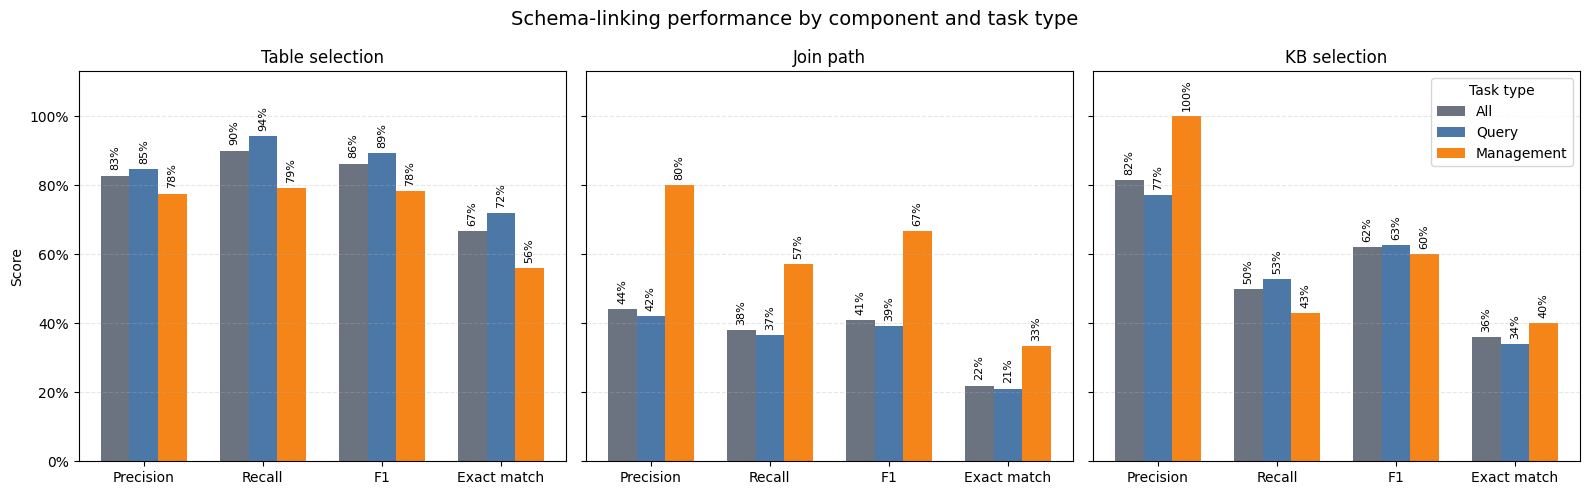

In [58]:
plot_specs = {
    'Table selection': ('table_precision', 'table_recall', 'table_f1', 'table_exact_match_rate'),
    'Join path': ('join_precision', 'join_recall', 'join_f1', 'join_path_exact_match_rate'),
    'KB selection': ('kb_precision', 'kb_recall', 'kb_f1', 'kb_exact_match_rate'),
}
metric_labels = ['Precision', 'Recall', 'F1', 'Exact match']
category_order = ['All', 'Query', 'Management']
category_colours = {'All': '#6B7280', 'Query': '#4C78A8', 'Management': '#F58518'}
x = np.arange(len(metric_labels)); width = 0.24
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (title, columns) in zip(axes, plot_specs.items()):
    for offset, category_name in enumerate(category_order):
        row = schema_linking_summary.set_index('category').loc[category_name]
        values = [row[column] for column in columns]
        positions = x + (offset - 1) * width
        bars = ax.bar(positions, values, width, label=category_name,
                      color=category_colours[category_name])
        for bar, value in zip(bars, values):
            if pd.notna(value):
                ax.text(bar.get_x() + bar.get_width()/2, value + 0.015,
                        f'{value:.0%}', ha='center', va='bottom', fontsize=8, rotation=90)
    ax.set_title(title); ax.set_xticks(x); ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1.13); ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
axes[0].set_ylabel('Score')
axes[-1].legend(title='Task type', loc='upper right')
fig.suptitle('Schema-linking performance by component and task type', fontsize=14)
plt.tight_layout(); plt.show()

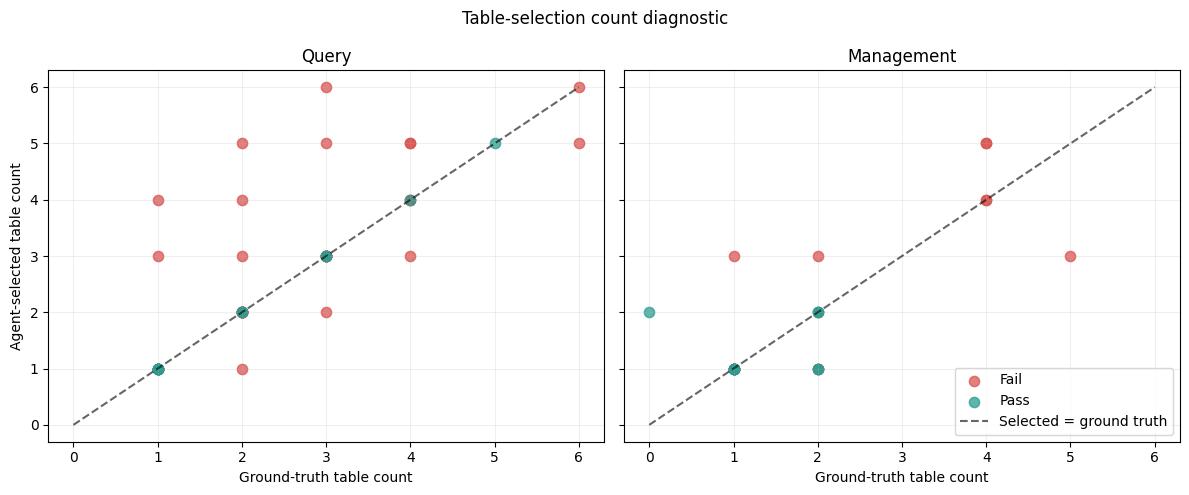

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
outcome_colours = {False: '#D9534F', True: '#2A9D8F'}
max_tables = int(max(analysis_df['table_selected_count'].max(),
                     analysis_df['table_ground_truth_count'].max()))
for ax, category_name in zip(axes, ['Query', 'Management']):
    subset = analysis_df[analysis_df['category'].eq(category_name)]
    for passed, label in [(False, 'Fail'), (True, 'Pass')]:
        points = subset[subset['phase1_passed'].eq(passed)]
        ax.scatter(points['table_ground_truth_count'], points['table_selected_count'],
                   s=55, alpha=0.75, color=outcome_colours[passed], label=label)
    ax.plot([0, max_tables], [0, max_tables], '--', color='black', alpha=0.6,
            label='Selected = ground truth')
    ax.set_title(category_name); ax.set_xlabel('Ground-truth table count')
    ax.set_xticks(range(max_tables + 1)); ax.set_yticks(range(max_tables + 1))
    ax.grid(alpha=0.2)
axes[0].set_ylabel('Agent-selected table count')
axes[-1].legend(loc='lower right')
fig.suptitle('Table-selection count diagnostic')
plt.tight_layout(); plt.show()

## Metrics by pipeline phase

Tool calls are grouped as follows: the six schema/column/knowledge retrieval tools are **pre-processing**; the first `execute_sql` is the only observable artifact for both implicit **query planning** and initial **SQL generation**; when that first execution fails, each later `execute_sql` is a **post-processing retry**. `submit_sql` is treated separately as the final overall outcome. Tasks whose first execution succeeds are not applicable to post-processing evaluation.

Because the first SQL is executed but not scored against ground truth, its semantic correctness is unknown. Planning metrics are therefore structural proxies. SQL generation has no separate metric in variant 0. Post-processing is observable only as retries triggered by an initial execution error, while final submitted-SQL success is reported separately as an overall outcome.

In [60]:
from trajectory_phase_metrics import add_phase_metrics

phase_df = add_phase_metrics(analysis_df)
display(phase_df[[
    'instance_id', 'category', 'preprocessing_call_count', 'schema_retrieved',
    'column_metadata_retrieved', 'phase_kb_precision', 'phase_kb_recall',
    'initial_table_precision', 'initial_table_recall',
    'initial_plan_structure_f1', 'first_execution_failed',
    'postprocessing_eligible',
    'postprocessing_attempt_count',
    'structure_changed_during_postprocessing', 'submission_present', 'final_passed',
]].head(20))

'DO $$
BEGIN
  IF NOT EXISTS (
    SELECT 1
    FROM pg_type
    WHERE typname = 'battery_efficiency_' contains unsupported syntax. Falling back to parsing as a 'Command'.
'DO $$
BEGIN
  IF NOT EXISTS (
    SELECT 1
    FROM pg_type
    WHERE typname = 'battery_efficiency_' contains unsupported syntax. Falling back to parsing as a 'Command'.
'DO $$
DECLARE
    rec    RECORD;
    v_fsi  NUMERIC(5,3);
BEGIN
    FOR rec IN
        SELECT e.empl' contains unsupported syntax. Falling back to parsing as a 'Command'.
'DO $$
BEGIN
  UPDATE employment_and_income e
  SET fsi = (
    0.35 * COALESCE(e.incstabscore, 0)::n' contains unsupported syntax. Falling back to parsing as a 'Command'.
'DO $$
DECLARE
    rec    RECORD;
    v_fsi  NUMERIC(5,3);
BEGIN
    FOR rec IN
        SELECT e.empl' contains unsupported syntax. Falling back to parsing as a 'Command'.
'DO $$
BEGIN
  UPDATE employment_and_income e
  SET fsi = (
    0.35 * COALESCE(e.incstabscore, 0)::n' contains unsupported syntax. Falling 

,instance_id,category,preprocessing_call_count,schema_retrieved,column_metadata_retrieved,phase_kb_precision,phase_kb_recall,initial_table_precision,initial_table_recall,initial_plan_structure_f1,first_execution_failed,postprocessing_eligible,postprocessing_attempt_count,structure_changed_during_postprocessing,submission_present,final_passed
0,gaming_1,Query,3,True,False,1.0,0.5,1.000000,1.00,0.857143,False,False,0,False,True,False
1,gaming_2,Query,5,True,True,1.0,1.0,1.000000,1.00,0.600000,False,False,0,True,True,False
2,gaming_3,Query,5,True,True,1.0,1.0,1.000000,0.25,NaN,False,False,0,True,True,True
3,gaming_4,Query,1,True,False,NaN,0.0,1.000000,1.00,1.000000,False,False,0,False,True,False
4,gaming_5,Query,1,True,False,NaN,0.0,1.000000,1.00,0.857143,False,False,0,False,True,False
5,gaming_6,Query,5,True,False,1.0,1.0,1.000000,1.00,1.000000,False,False,0,False,True,False
6,gaming_7,Query,1,True,False,NaN,0.0,0.333333,1.00,0.571429,False,False,0,True,True,False
7,gaming_8,Query,2,True,True,NaN,0.0,0.666667,0.50,1.000000,False,False,0,False,True,False
8,gaming_9,Query,2,True,True,NaN,0.0,1.000000,1.00,0.857143,False,False,0,False,True,False
9,gaming_10,Query,6,True,True,1.0,1.0,1.000000,1.00,0.750000,False,False,0,False,True,True


In [61]:
from schema_linking_metrics import micro_scores

phase_rows = []
for category_name, subset in [('All', phase_df), *phase_df.groupby('category', observed=True)]:
    kb = micro_scores(subset, 'phase_kb')
    tables = micro_scores(subset, 'initial_table')
    join_subset = subset[subset['initial_join_path_ground_truth_count'].gt(0)]
    joins = micro_scores(join_subset, 'initial_join_path')
    plan = micro_scores(subset, 'initial_plan_structure')
    eligible = subset[subset['postprocessing_eligible']]
    phase_rows.append({
        'category': category_name, 'tasks': len(subset),
        'pre_schema_use': subset['schema_retrieved'].mean(),
        'pre_column_metadata_use': subset['column_metadata_retrieved'].mean(),
        'pre_kb_precision': kb['precision'], 'pre_kb_recall': kb['recall'], 'pre_kb_f1': kb['f1'],
        'pre_initial_table_f1': tables['f1'], 'pre_initial_join_f1': joins['f1'],
        'planning_structure_precision': plan['precision'],
        'planning_structure_recall': plan['recall'], 'planning_structure_f1': plan['f1'],
        'planning_structure_exact': subset['plan_structure_exact_match'].mean(),
        'post_eligible_tasks': len(eligible),
        'post_retry_rate_after_error': eligible['postprocessing_attempted'].mean(),
        'post_total_retries_after_error': eligible['postprocessing_attempt_count'].sum(),
        'post_avg_retries_per_initial_error': eligible['postprocessing_attempt_count'].mean(),
        'post_avg_retries_when_retried': eligible.loc[
            eligible['postprocessing_attempted'], 'postprocessing_attempt_count'
        ].mean(),
        'post_error_resolution_rate': eligible['initial_execution_error_resolved'].mean(),
    })
phase_summary = pd.DataFrame(phase_rows)
percentage_columns = [c for c in phase_summary if c not in {
    'category', 'tasks', 'post_eligible_tasks', 'post_total_retries_after_error',
    'post_avg_retries_per_initial_error', 'post_avg_retries_when_retried'
}]
display(phase_summary.style.format({**{c: '{:.1%}' for c in percentage_columns},
                                    'post_avg_retries_per_initial_error': '{:.2f}',
                                    'post_avg_retries_when_retried': '{:.2f}'}))
phase_summary.to_csv('results/eval_7db_train_phase_summary.csv', index=False)
phase_df.to_csv('results/eval_7db_train_phase_tasks.csv', index=False)

overall_success = (phase_df.groupby('category', observed=True)['final_passed']
                   .agg(tasks='size', passed='sum', final_success_rate='mean')
                   .reset_index())
overall_success.loc[len(overall_success)] = [
    'All', len(phase_df), int(phase_df['final_passed'].sum()), phase_df['final_passed'].mean()
]
display(overall_success.style.format({'final_success_rate': '{:.1%}'}))

,category,tasks,pre_schema_use,pre_column_metadata_use,pre_kb_precision,pre_kb_recall,pre_kb_f1,pre_initial_table_f1,pre_initial_join_f1,planning_structure_precision,planning_structure_recall,planning_structure_f1,planning_structure_exact,post_eligible_tasks,post_retry_rate_after_error,post_total_retries_after_error,post_avg_retries_per_initial_error,post_avg_retries_when_retried,post_error_resolution_rate
0,All,75,98.7%,49.3%,81.6%,50.0%,62.0%,80.4%,32.8%,62.9%,72.1%,67.2%,17.3%,17,58.8%,13,0.76,1.30,58.8%
1,Management,25,96.0%,40.0%,100.0%,42.9%,60.0%,65.1%,46.2%,49.3%,62.3%,55.0%,20.0%,13,46.2%,7,0.54,1.17,46.2%
2,Query,50,100.0%,54.0%,77.0%,52.8%,62.7%,85.6%,31.7%,67.7%,75.1%,71.2%,16.0%,4,100.0%,6,1.50,1.50,100.0%


,category,tasks,passed,final_success_rate
0,Management,25,9,36.0%
1,Query,50,12,24.0%
2,All,75,21,28.0%


### Metric scope by experimental variant

The variant 0 metrics form the common baseline and should remain available for every later variant. Variants 1–3 may add diagnostic metrics when their new agent or harness components make those events directly observable.

| Phase | Variant 0 baseline | Possible expansion in variants 1–3 |
|---|---|---|
| Pre-processing | Table, column, join-path, and KB F1 | Explicit selector accuracy, coverage checks, retrieval ranking |
| Query planning | SQL-inferred operation, condition, strategy, and structural match | Explicit plan coverage, result-grain accuracy, plan validation |
| SQL generation | No separate metric | Plan adherence and initial-candidate validity when a draft is recorded |
| Post-processing | Initial-error count, retry rate, average retries, error-resolution rate | Attempt purpose, semantic correction, regression, and correction efficiency |
| Overall | Final submitted-SQL success | Remains the common end-to-end outcome |

Additional metrics must supplement rather than replace the variant 0 measures, so comparisons across all four variants remain fair.